In [3]:
!pip install torch
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.4 MB/s eta 0:00:00


In [4]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch import nn
import pandas as pd # this module is useful to work with tabular data
import random # this module will be used to select random samples from a collection
import os # this module will be used just to create directories in the local filesystem
from tqdm import tqdm # this module is useful to plot progress bars
import torch.nn.functional as F
from PIL import Image # to interact with images
from sklearn.model_selection import KFold

# FashionMNIST Dataset

In [7]:
train_dataset = torchvision.datasets.FashionMNIST('classifier_data', train=True, download=True)
test_dataset  = torchvision.datasets.FashionMNIST('classifier_data', train=False, download=True)

100%|██████████████████████████████████████| 26.4M/26.4M [00:05<00:00, 5.14MB/s]
100%|██████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 1.37MB/s]
100%|██████████████████████████████████████| 4.42M/4.42M [00:01<00:00, 2.69MB/s]
100%|██████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 3.60MB/s]


In [8]:
# Dictionary containing the mapping from label name to ID
label_to_id = {
  'T-shirt/top': 0,
  'Trouser': 1,
  'Pullover': 2,
  'Dress': 3,
  'Coat': 4,
  'Sandal': 5,
  'Shirt': 6,
  'Sneaker': 7,
  'Bag': 8,
  'Ankle boot': 9,
}
# Dictionary containing the mapping from ID to label name
id_to_label = {id: label for label, id in label_to_id.items()}

print('label_to_id =', label_to_id)
print('id_to_label =', id_to_label)

label_to_id = {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
id_to_label = {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}


### Transformations 

In [9]:
# Set the train transform
scale = 300
input_shape = 224
train_trans = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean = 0.2859, std = 0.3530),
        ])

# Set the test transform
test_trans = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize(mean = 0.2859, std = 0.3530)]) 

ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])
ORIGINAL IMAGE SHAPE: (28, 28)
TRANSFORMED IMAGE SHAPE: torch.Size([1, 28, 28])


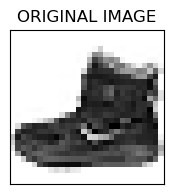

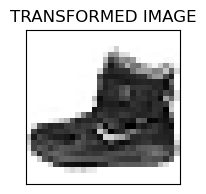

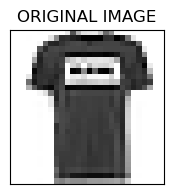

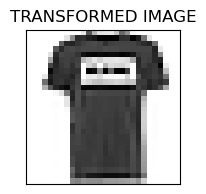

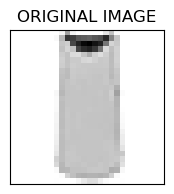

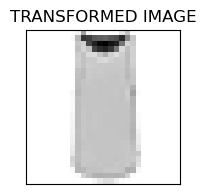

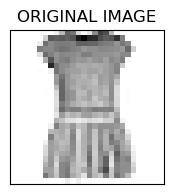

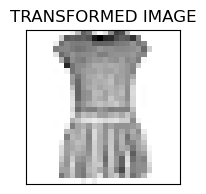

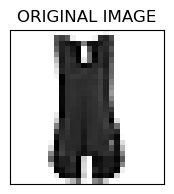

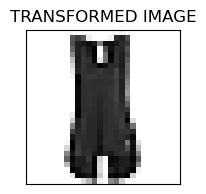

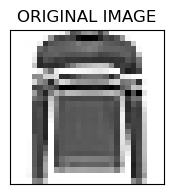

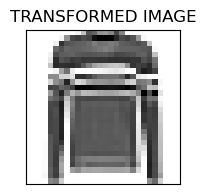

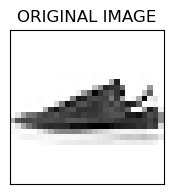

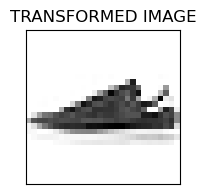

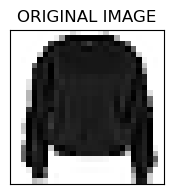

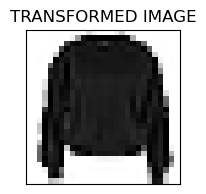

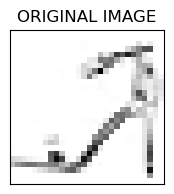

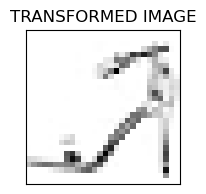

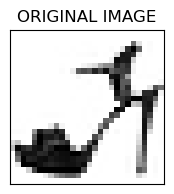

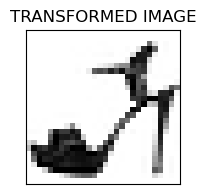

In [10]:
# Test if it works
for i in range(10):
    original_image = train_dataset[i][0]
    transformed_image = test_trans(original_image)
    print(f"ORIGINAL IMAGE SHAPE: {np.array(original_image).shape}")
    print(f"TRANSFORMED IMAGE SHAPE: {transformed_image.shape}")

    # Plot original image
    fig, ax = plt.subplots(figsize=(2, 2))
    plt.title('ORIGINAL IMAGE')
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(original_image, cmap='Greys')

    # Plot transformed image
    transformed_image = torch.squeeze(transformed_image)
    fig, ax = plt.subplots(figsize=(2, 2))
    plt.title('TRANSFORMED IMAGE')
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(transformed_image, cmap='Greys')

### Dataset class

In [11]:
class ImageDataset(Dataset):
    
    def __init__(self, samples, transform=None):
      """
      samples: list of samples where each element is a tuple (image_path, class_name)
      """
      self.samples = samples
      self.transform = transform

    def __len__(self):
      return len(self.samples)

    def __getitem__(self, idx):
      # Get the corresponding sample
      image, label = self.samples[idx]

      # Apply transformations (to the image only)
      if self.transform:
          image = self.transform(image)

      return (image, label)

In [12]:
#Set the transformations
train_dataset.transform = train_trans
test_dataset.transform = test_trans

test_dataloader = DataLoader(test_dataset, batch_size=200, shuffle=False, num_workers=2)


# Train & Testing functions

In [13]:
### Training function
def train_epoch(net, device, train_dataloader, loss_fn, optimizer):

    net.train()
    train_loss_batches = []
    correct = 0
    for sample_batched in train_dataloader:     # Iterate the dataloader
      # Move data to device (ex. on the GPU)
        image_batch = sample_batched[0].to(device)    
        label_batch = sample_batched[1].to(device)
      # Encode data
        out = net(image_batch)
      # Compute loss
        loss = loss_fn(out, label_batch)
      # Backpropagation
        optimizer.zero_grad()
        loss.backward()
      # Update the weights
        optimizer.step()

      # Save train loss for this batch
        loss_batch = loss.detach().cpu().numpy()  #detach-->export to the cpu --> export in numpy
        train_loss_batches.append(loss_batch)

      # Classification step
        pred = out.max(1, keepdim=True)[1] # get the index of the max logit
        correct += pred.eq(label_batch.view_as(pred)).sum().item()

    tot_images = len(train_dataloader)*200
    accuracy = 100. * correct / tot_images
    print(f'Average train loss: {np.mean(train_loss_batches)}, Accuracy: {correct}/{tot_images}: {accuracy}%')

    return accuracy

In [14]:
### Validation-Testing function
def val_epoch(net, device, val_dataloader, loss_fn):

    net.eval()
    val_loss_batches = []
    correct = 0
    with torch.no_grad(): # Disable gradient tracking since we don't want to update the net during Testing
        for sample_batched in val_dataloader:
          # Move data to device
            image_batch = sample_batched[0].to(device)
            label_batch = sample_batched[1].to(device)
          # Encode data
            out = net(image_batch)
          # Compute loss
            loss = loss_fn(out, label_batch)
          # Save val loss for this batch
            loss_batch = loss.detach().cpu().numpy()
            val_loss_batches.append(loss_batch)

        # Classification step
            pred = out.max(1, keepdim=True)[1] # get the index of the max logit
            correct += pred.eq(label_batch.view_as(pred)).sum().item()

    tot_images = len(val_dataloader)*200
    accuracy = 100. * correct / tot_images
    print(f'Average validation loss: {np.mean(val_loss_batches)}, Accuracy: {correct}/{tot_images}: {accuracy}%')

    return accuracy

# Feed-forward Classifier

In [15]:
class Net(nn.Module):
    
    def __init__(self, Ni, Nh1, Nh2, No, dropout=0):   #2 hidden layer
        """
        Ni - Input size
        Nh1 - Neurons in the 1st hidden layer
        Nh2 - Neurons in the 2nd hidden layer
        No - Output size
        """
        super().__init__()                        # super() calls the parent class nn.Module
        self.flatten = nn.Flatten(start_dim=1)
        
        self.ffnn = nn.Sequential(
                    # First linear layer
                    nn.Linear(in_features=Ni, out_features=Nh1),
                    nn.BatchNorm1d(Nh1),
                    nn.ReLU(True),
                    # Second linear layer
                    nn.Linear(in_features=Nh1, out_features=Nh2),
                    nn.BatchNorm1d(Nh2),
                    nn.ReLU(True),
                    nn.Dropout(dropout),
                    #Output layer
                    nn.Linear(in_features=Nh2, out_features=No)
        )

        
    def forward(self, x, additional_out=False):  # Forward pass of the network, from the input x to the output. 

        x = self.flatten(x)                    
        x = self.ffnn(x)
        return x

In [16]:
# Check if the GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f"Training device: {device}")

Training device: cpu


In [17]:
# Initialize the network
torch.manual_seed(0) # Set the random seed for reproducible results
Ni = 28*28
Nh1 = 2500
Nh2 = 2000
No = 10
net = Net(Ni, Nh1, Nh2, No, dropout=0.5)
net.to(device)

Net(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (ffnn): Sequential(
    (0): Linear(in_features=784, out_features=2500, bias=True)
    (1): BatchNorm1d(2500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=2500, out_features=2000, bias=True)
    (4): BatchNorm1d(2000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=2000, out_features=10, bias=True)
  )
)

## Optuna for Hyperparameters Tuning + 3Fold Cross Validation

In [18]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [optuna]


In [33]:
from torch.nn.modules import dropout
import optuna
import torch.nn.functional as F
#from optuna.integration import PyTorchLightningPruningCallback
from optuna.trial import TrialState

In [36]:
def objective_cv(trial):

    fold = KFold(n_splits=3, shuffle=True, random_state=0) #provides train/test indices to split data in train/val sets
    train_accuracies, val_accuracies = [], []
    k = 0
    for fold_idx, (train_idx, val_idx) in enumerate(fold.split(range(len(train_dataset)))):
        train_data = torch.utils.data.Subset(train_dataset, train_idx)
        val_data = torch.utils.data.Subset(train_dataset, val_idx)

        train_dataloader = DataLoader(train_data, batch_size=200, shuffle=True, num_workers=2)
        val_dataloader = DataLoader(val_data, batch_size=200, shuffle=False, num_workers=2)
        k += 1
        print(f'FOLD {k}')
        #train_accuracy, val_accuracy = objective(trial, train_dataloader, val_dataloader)
        val_accuracy = objective(trial, train_dataloader, val_dataloader)
        trial.report(val_accuracy, k)

        # Handle pruning based on the intermediate value.
        if trial.should_prune():
            raise optuna.TrialPruned()

        val_accuracies.append(val_accuracy)
        #train_accuracies.append(train_accuracy)

    #return np.mean(train_accuracies), np.mean(val_accuracies)
    return np.mean(val_accuracies)

def objective(trial, train_dataloader, val_dataloader):

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    dropout = trial.suggest_float('dropout', 0.1, 0.7) 
    model = Net(Ni, Nh1, Nh2, No, dropout).to(device)

    # Define the loss function
    loss_fn =  nn.CrossEntropyLoss()  
    # Define the optimizer
    lr = trial.suggest_float('lr', 1e-5, 1e-3) 
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2) 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    print(f'Trail with dropout:{dropout}, adam_lr:{lr}, weight_decay:{weight_decay}')

    num_epochs = 20     #1epoch=1iter over your data
    for epoch_num in range(num_epochs):

      print(f'# EPOCH {epoch_num+1}')
      train_accuracy = train_epoch(model, device, train_dataloader, loss_fn, optimizer)
      val_accuracy = val_epoch(model, device, val_dataloader, loss_fn)

    #return train_accuracy, val_accuracy
    return val_accuracy

In [ ]:
# Study initialization
# sampler = 'TPEsampler' : default paramter for single-objective optimization
# pruner = 'MedianPruner' : default paramter for pruning useless configurations

study = optuna.create_study(study_name="FashionMNIST", direction="maximize")

# Opimization
# Recevies the function to be optimized and the number of trials
study.optimize(objective_cv, n_trials=10)
pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))
print("  Number of pruned trials: ", len(pruned_trials))
print("  Number of complete trials: ", len(complete_trials))

print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))
    

#At the end it will tell us the best set of parameters after n_trails

In [ ]:
torch.save(study.get_trials(), 'optuna_trials.torch')

### Analyze the trials

In [ ]:
complete_trials = study.get_trials()
for i in range(10):
  print(complete_trials[i].params)
  print(complete_trials[i].values[0])

{'dropout': 0.14720335836910695, 'lr': 0.00021301491234202867, 'weight_decay': 0.005434936251453934}
87.27666666666666
{'dropout': 0.16298409978403045, 'lr': 0.0005641805832799336, 'weight_decay': 0.006466329074300062}
86.94999999999999
{'dropout': 0.6406806524045935, 'lr': 0.0007503626278539724, 'weight_decay': 0.00028348475807963354}
88.61833333333334
{'dropout': 0.5238178468349262, 'lr': 0.00037599255934598534, 'weight_decay': 0.001507633829502709}
87.99499999999999
{'dropout': 0.37118808754038446, 'lr': 0.00034342081394878136, 'weight_decay': 0.007366920718115674}
87.47166666666668
{'dropout': 0.11986566039132894, 'lr': 0.0009423241934056189, 'weight_decay': 0.007935090647553678}
86.625
{'dropout': 0.2798783951511744, 'lr': 0.0002532466290862234, 'weight_decay': 0.001675196925289427}
86.59499999999998
{'dropout': 0.6199376383308572, 'lr': 0.0006271385588318729, 'weight_decay': 0.009924658461651857}
87.265
{'dropout': 0.6878789514785971, 'lr': 0.00021139192114900168, 'weight_decay':

In [37]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
labels = []
for i in range(10):
    labels.append(f'Trail {i+1}')

fig = make_subplots(rows=2, cols=2, subplot_titles=("Val accuracy in %", "dropout ", "lr", "weight decay"))
fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].values[0] for i in range(10)],
          text=["%.3f" % complete_trials[i].values[0] for i in range(10)],
          textposition='auto',
      ), 1,1)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['dropout'] for i in range(10)],
          text=["%.3f" % complete_trials[i].params['dropout'] for i in range(10)],
          textposition='auto',
      ), 1,2)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['weight_decay'] for i in range(10)],
          text=["%.1e" % complete_trials[i].params['weight_decay'] for i in range(10)],
          textposition='auto',
      ), 2,2)


fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['lr'] for i in range(10)],
          text=["%.1e" % complete_trials[i].params['lr'] for i in range(10)],
          textposition='auto',
      ), 2, 1)

fig.show()

### Best Model evaluated on the whole training set

In [ ]:
dropout = study.best_trial.params['dropout']
bestFF_model = Net(Ni, Nh1, Nh2, No, dropout).to(device)

# Define the loss function
loss_fn =  nn.CrossEntropyLoss()  
# Define the optimizer
weight_decay = study.best_trial.params['weight_decay']
lr = study.best_trial.params['lr']
optimizer = torch.optim.Adam(bestFF_model.parameters(), lr=lr, weight_decay=weight_decay)

train_dataloader = DataLoader(train_dataset, batch_size=200, shuffle=True, num_workers=2)

### TRAINING LOOP
train_acc, test_acc = [], []
num_epochs = 100
for epoch_num in range(num_epochs):

    print(f'# EPOCH {epoch_num+1}')
    accuracy = train_epoch(bestFF_model, device, train_dataloader, loss_fn, optimizer)
    train_acc.append(accuracy)

    accuracy = val_epoch(bestFF_model, device, test_dataloader, loss_fn)
    test_acc.append(accuracy)

# EPOCH 1
Average train loss: 0.45375189185142517, Accuracy: 50074/60000: 83.45666666666666%
Average validation loss: 0.42292582988739014, Accuracy: 8463/10000: 84.63%
# EPOCH 2
Average train loss: 0.3574296236038208, Accuracy: 52124/60000: 86.87333333333333%
Average validation loss: 0.3547033965587616, Accuracy: 8707/10000: 87.07%
# EPOCH 3
Average train loss: 0.32890522480010986, Accuracy: 52711/60000: 87.85166666666667%
Average validation loss: 0.36677485704421997, Accuracy: 8648/10000: 86.48%
# EPOCH 4
Average train loss: 0.31367501616477966, Accuracy: 53031/60000: 88.385%
Average validation loss: 0.35756194591522217, Accuracy: 8710/10000: 87.1%
# EPOCH 5
Average train loss: 0.3004549443721771, Accuracy: 53400/60000: 89.0%
Average validation loss: 0.3431795835494995, Accuracy: 8761/10000: 87.61%
# EPOCH 6
Average train loss: 0.285245418548584, Accuracy: 53703/60000: 89.505%
Average validation loss: 0.3515801727771759, Accuracy: 8767/10000: 87.67%
# EPOCH 7
Average train loss: 0.275

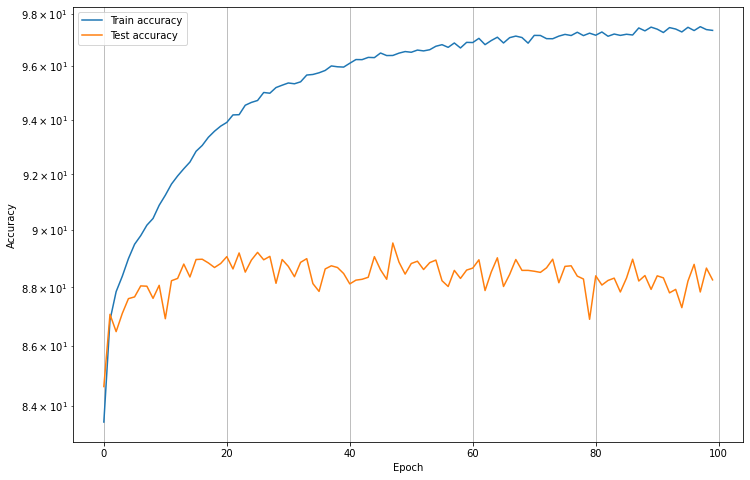

In [ ]:
# Accuracy
plt.figure(figsize=(12,8))
plt.semilogy(train_acc, label='Train accuracy')
plt.semilogy(test_acc, label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel(f'Accuracy')
plt.grid()
plt.legend()
plt.show()

In [ ]:
#Save the network
torch.save(bestFF_model.state_dict(), 'MLP_model.torch')
#Save the optimizer state
torch.save(optimizer.state_dict(), 'MLP_optimizer.torch')

# Convolutional Classifier

In [38]:
class Net(nn.Module):
    def __init__(self, dropout=0.1, dropout_ff=0.3):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2_drop = nn.Dropout2d(dropout)
        self.conv2_bn = nn.BatchNorm2d(20)
        self.fc1 = nn.Linear(320, 50)
        self.fc1_bn = nn.BatchNorm1d(50)
        self.fc1_drop = nn.Dropout(dropout_ff)
        self.fc1ReLU = nn.ReLU()
        self.fc2 = nn.Linear(50, 10)
        

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(F.max_pool2d(x, 2))
        x = self.conv2(x)
        x = self.conv2_bn(x)
        x = F.relu(F.max_pool2d(self.conv2_drop(x), 2))
        x = x.view(-1, 320)
        x = self.fc1_bn(self.fc1(x))
        x = self.fc1ReLU(x)
        x = self.fc1_drop(x)
        x = self.fc2(x)
        return x

## Hyperparameters Tuning with Optuna

In [39]:
def objective_cv(trial):

    fold = KFold(n_splits=3, shuffle=True, random_state=0) #provides train/test indices to split data in train/val sets
    train_accuracies, val_accuracies = [], []
    k = 0
    for fold_idx, (train_idx, val_idx) in enumerate(fold.split(range(len(train_dataset)))):
        train_data = torch.utils.data.Subset(train_dataset, train_idx)
        val_data = torch.utils.data.Subset(train_dataset, val_idx)

        train_dataloader = DataLoader(train_data, batch_size=200, shuffle=True, num_workers=2)
        val_dataloader = DataLoader(val_data, batch_size=200, shuffle=False, num_workers=2)
        k += 1
        print(f'FOLD {k}')
        #train_accuracy, val_accuracy = objective(trial, train_dataloader, val_dataloader)
        val_accuracy = objective(trial, train_dataloader, val_dataloader)
        trial.report(val_accuracy, k)

        # Handle pruning based on the intermediate value.
        if trial.should_prune():
            raise optuna.TrialPruned()

        val_accuracies.append(val_accuracy)
        #train_accuracies.append(train_accuracy)

    #return np.mean(train_accuracies), np.mean(val_accuracies)
    return np.mean(val_accuracies)

def objective(trial, train_dataloader, val_dataloader):

    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
    dropout = trial.suggest_float('dropout', 0.1, 0.3) 
    dropout_ff = trial.suggest_float('dropout_ff', 0.1, 0.5) 
    model = Net(dropout, dropout_ff).to(device)

    # Define the loss function
    loss_fn =  nn.CrossEntropyLoss()  
    # Define the optimizer
    #weight_decay_exp = trial.suggest_int('weight_decay_exp', 2, 5)
    #adam_lr_exp = trial.suggest_int('adam_lr_exp', 2, 5)
    #optimizer = torch.optim.Adam(model.parameters(), lr=10**(-1*adam_lr_exp), weight_decay=10**(-1*weight_decay_exp))
    #print(f'Trail with dropout:{dropout}, adam_lr_exp:{adam_lr_exp}, weight_decay_exp:{weight_decay_exp}')
    lr = trial.suggest_float('lr', 1e-5, 1e-3) 
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-4) 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    print(f'Trail with dropout:{dropout}, dropout_ff:{dropout_ff}, adam_lr:{lr}, weight_decay:{weight_decay}')

    num_epochs = 15     #1epoch=1iter over your data
    for epoch_num in range(num_epochs):

      print(f'# EPOCH {epoch_num+1}')
      train_accuracy = train_epoch(model, device, train_dataloader, loss_fn, optimizer)
      val_accuracy = val_epoch(model, device, val_dataloader, loss_fn)

    #return train_accuracy, val_accuracy
    return val_accuracy

In [ ]:
# Study initialization
# sampler = 'TPEsampler' : default paramter for single-objective optimization
# pruner = 'MedianPruner' : default paramter for pruning useless configurations

study = optuna.create_study(study_name="FashionMNIST", direction="maximize")

# Opimization
# Recevies the function to be optimized and the number of trials
study.optimize(objective_cv, n_trials=10)
pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("Study statistics: ")
print("  Number of finished trials: ", len(study.trials))
print("  Number of pruned trials: ", len(pruned_trials))
print("  Number of complete trials: ", len(complete_trials))

print("Best trial:")
trial = study.best_trial

print("  Value: {}".format(trial.value))

print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))
    

#At the end it will tell us the best set of parameters after n_trails

In [ ]:
torch.save(study.get_trials(), 'optuna_trials.torch')

In [ ]:
# Load the state dict previously saved
complete_trials = torch.load('CNN_optuna_trials.torch')

### Analyze the trials

In [ ]:
# = study.get_trials()
print(complete_trials)
for i in range(10):
  print(complete_trials[i].params)
  print(complete_trials[i].values[0])

[FrozenTrial(number=0, values=[89.795], datetime_start=datetime.datetime(2021, 12, 30, 8, 2, 54, 838273), datetime_complete=datetime.datetime(2021, 12, 30, 8, 15, 46, 374418), params={'dropout': 0.1939248716879456, 'dropout_ff': 0.41247160945697525, 'lr': 0.000863395789405621, 'weight_decay': 4.223708873412977e-05}, distributions={'dropout': UniformDistribution(high=0.3, low=0.1), 'dropout_ff': UniformDistribution(high=0.5, low=0.1), 'lr': UniformDistribution(high=0.001, low=1e-05), 'weight_decay': UniformDistribution(high=0.0001, low=1e-06)}, user_attrs={}, system_attrs={}, intermediate_values={1: 89.765, 2: 90.095, 3: 89.525}, trial_id=0, state=TrialState.COMPLETE, value=None), FrozenTrial(number=1, values=[89.52999999999999], datetime_start=datetime.datetime(2021, 12, 30, 8, 15, 46, 379709), datetime_complete=datetime.datetime(2021, 12, 30, 8, 28, 26, 420992), params={'dropout': 0.24044013286742175, 'dropout_ff': 0.12160876320466207, 'lr': 0.00029974457502313285, 'weight_decay': 5.8

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
labels = []
for i in range(10):
    labels.append(f'Trail {i+1}')

fig = make_subplots(rows=3, cols=2, subplot_titles=("Val accuracy in %", "dropout conv","lr", "dropout lin","", "weight decay"))
fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].values[0] for i in range(10)],
          text=["%.3f" % complete_trials[i].values[0] for i in range(10)],
          textposition='auto',
      ), 1,1)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['dropout'] for i in range(10)],
          text=["%.3f" % complete_trials[i].params['dropout'] for i in range(10)],
          textposition='auto',
      ), 1,2)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['weight_decay'] for i in range(10)],
          text=["%.1e" % complete_trials[i].params['weight_decay'] for i in range(10)],
          textposition='auto',
      ), 3,2)


fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['lr'] for i in range(10)],
          text=["%.1e" % complete_trials[i].params['lr'] for i in range(10)],
          textposition='auto',
      ), 2, 1)

fig.add_trace(go.Bar(
          x=labels, 
          y=[complete_trials[i].params['dropout_ff'] for i in range(10)],
          text=["%.3f" % complete_trials[i].params['dropout_ff'] for i in range(10)],
          textposition='auto',

      ), 2, 2)
fig.show()

### BEST CNN

In [ ]:
#BEST MODEL

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

dropout = study.best_trial.params['dropout']
dropout_ff = study.best_trial.params['dropout_ff']
best_model = Net(dropout,dropout_ff).to(device)
train_dataloader = DataLoader(train_dataset, batch_size=200, shuffle=True, num_workers=2)

# Define the loss function
loss_fn =  nn.CrossEntropyLoss()  
# Define the optimizer
weight_decay = study.best_trial.params['weight_decay']
lr = study.best_trial.params['lr']
optimizer = torch.optim.Adam(best_model.parameters(), lr=lr, weight_decay=weight_decay)

num_epochs = 100     #1epoch=1iter over your data
train_acc, test_acc = [], []
for epoch_num in range(num_epochs):

    print(f'# EPOCH {epoch_num}')
    accuracy = train_epoch(best_model, device, train_dataloader, loss_fn, optimizer)
    train_acc.append(accuracy)

    accuracy = val_epoch(best_model, device, test_dataloader, loss_fn)
    test_acc.append(accuracy)

# EPOCH 0
Average train loss: 0.8038527369499207, Accuracy: 45460/60000: 75.76666666666667%
Average validation loss: 0.44568154215812683, Accuracy: 8497/10000: 84.97%
# EPOCH 1
Average train loss: 0.42572271823883057, Accuracy: 51222/60000: 85.37%
Average validation loss: 0.37173667550086975, Accuracy: 8671/10000: 86.71%
# EPOCH 2
Average train loss: 0.3698875606060028, Accuracy: 52179/60000: 86.965%
Average validation loss: 0.3458254635334015, Accuracy: 8720/10000: 87.2%
# EPOCH 3
Average train loss: 0.33739855885505676, Accuracy: 52779/60000: 87.965%
Average validation loss: 0.32375475764274597, Accuracy: 8834/10000: 88.34%
# EPOCH 4
Average train loss: 0.3240973651409149, Accuracy: 53019/60000: 88.365%
Average validation loss: 0.3093321919441223, Accuracy: 8874/10000: 88.74%
# EPOCH 5
Average train loss: 0.30985283851623535, Accuracy: 53412/60000: 89.02%
Average validation loss: 0.3044974207878113, Accuracy: 8900/10000: 89.0%
# EPOCH 6
Average train loss: 0.29464834928512573, Accura

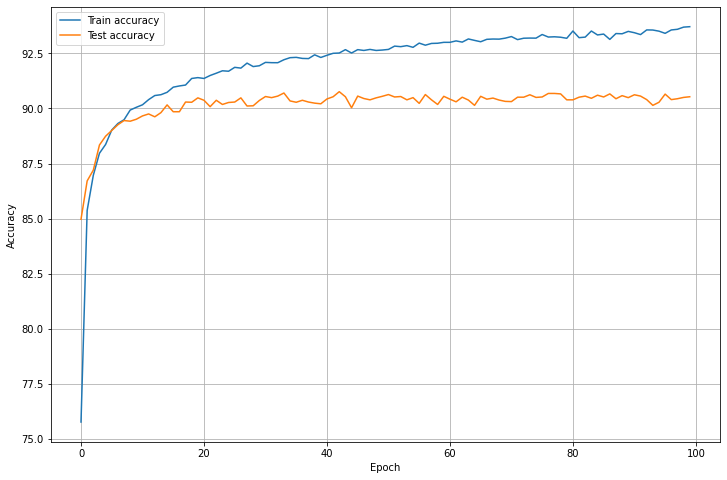

In [ ]:
# Plot accuracy
plt.figure(figsize=(12,8))
plt.plot(train_acc, label='Train accuracy')
plt.plot(test_acc, label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Save network parameters
print(best_model.state_dict().keys())
torch.save(best_model.state_dict(), 'CNN_params.torch')
### Save the optimizer state
torch.save(optimizer.state_dict(), 'CNN_optimizer_state.torch')

odict_keys(['conv1.weight', 'conv1.bias', 'conv2.weight', 'conv2.bias', 'conv2_bn.weight', 'conv2_bn.bias', 'conv2_bn.running_mean', 'conv2_bn.running_var', 'conv2_bn.num_batches_tracked', 'fc1.weight', 'fc1.bias', 'fc1_bn.weight', 'fc1_bn.bias', 'fc1_bn.running_mean', 'fc1_bn.running_var', 'fc1_bn.num_batches_tracked', 'fc2.weight', 'fc2.bias'])


In [ ]:
#dropout = study.best_trial.params['dropout']
#dropout_ff = study.best_trial.params['dropout_ff']
dropout = 0.16801027903950977
dropout_ff = 0.16573496668551163
best_model = Net(dropout,dropout_ff).to(device)
# Load the state dict previously saved
net_state_dict = torch.load('CNN_params.torch', map_location=torch.device('cpu'))
# Update the network parameters
best_model.load_state_dict(net_state_dict)

<All keys matched successfully>

### Confusion matrix

In [40]:
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / np.sum(cm).astype('float')
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(15, 10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()


## Testing function

In [41]:
### Testing function
def test_epoch(net, device, dataloader, loss_fn):
    # Set evaluation mode
    net.eval()
    with torch.no_grad(): # No need to track the gradients
        # Define the lists to store the outputs for each batch
        conc_in = []
        conc_out = []
        conc_label = []
        for image_batch, label_batch in tqdm(dataloader):
            # Move tensor to the proper device
            image_batch = image_batch.to(device)
            label_batch = label_batch.to(device)
            # Forward pass
            out = net(image_batch)
            # Append the network output and the original image to the lists
            conc_in.append(image_batch)
            conc_out.append(out)
            conc_label.append(label_batch)
        # Create a single tensor with all the values in the lists
        conc_in = torch.cat(conc_in)
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label) 
        # Evaluate global loss
        test_loss = loss_fn(conc_out, conc_label)
    return conc_in, conc_out, conc_label, test_loss.data # We return all the outputs, all the labels and the global loss

100%|██████████| 50/50 [00:01<00:00, 30.29it/s]


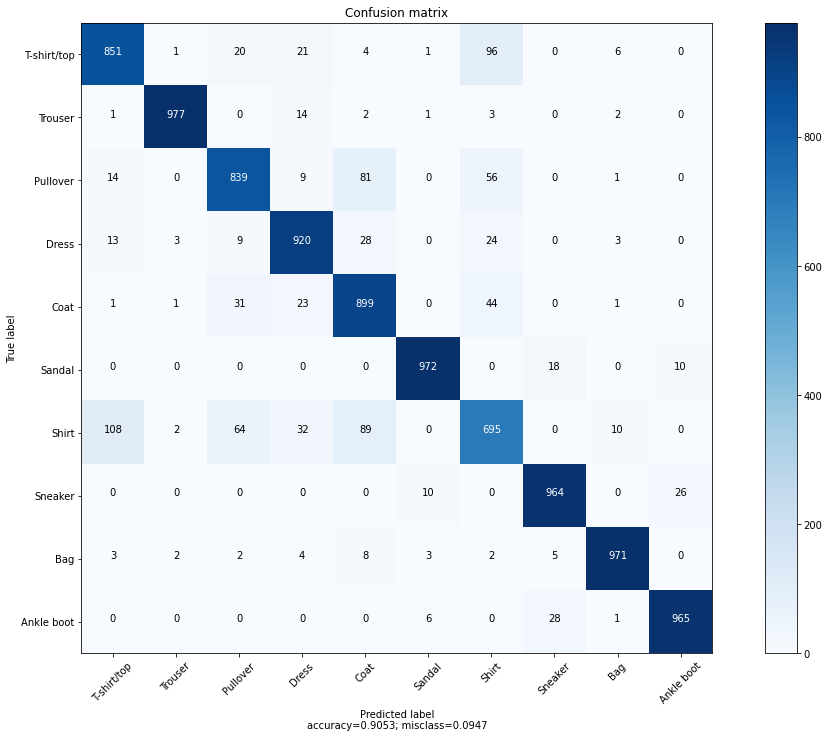

In [ ]:
from sklearn import metrics, manifold

loss_fn =  nn.CrossEntropyLoss()
test_inputs, test_outputs, test_labels, test_loss = test_epoch(
    net=best_model,
    device=device, 
    dataloader=test_dataloader, 
    loss_fn=loss_fn)

### Confusion matrix
# Predicted labels
y_true = test_labels.cpu().data
y_out = test_outputs.cpu()
y_pred = test_outputs.cpu().argmax(dim=1)
# Evaluate confusion matrix
cm = metrics.confusion_matrix(y_true, y_pred)
# Show the confusion matrix
#pd.DataFrame(cm)
plot_confusion_matrix(cm, target_names=train_dataset.classes, normalize=False)


# Network analysis

### Misclassified Images

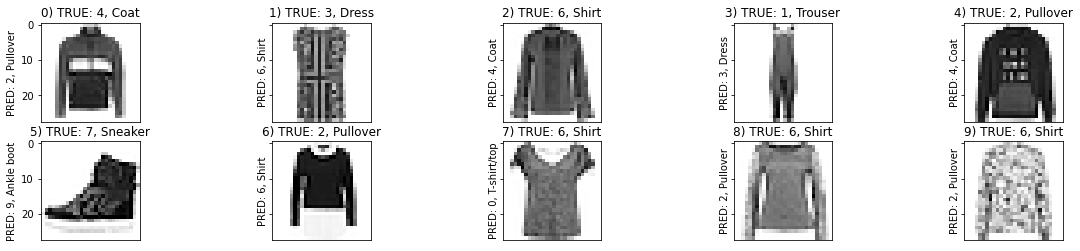

In [ ]:
#Examples of Misclassified Images
misclass_i = torch.nonzero(y_true-y_pred)
misclass_images = test_inputs[misclass_i]
misclass_out = y_out[misclass_i]
misclass_pred = y_pred[misclass_i]
misclass_label = y_true[misclass_i]

softmax_outs = []
fig, axs = plt.subplots(2,5, figsize =(20, 4), sharey=True)
for i in range(10) :
    index = random.randint(0, len(misclass_images))
    sample_image = misclass_images[index]
    label = misclass_label[index].numpy()[0]
    pred = misclass_pred[index].numpy()[0]
    out = misclass_out[index]
    softmax_out = torch.nn.functional.softmax(out, dim=1)
    softmax_out = softmax_out.flatten().numpy()
    softmax_outs.append(softmax_out)

    #Plot
    sample_image = torch.squeeze(sample_image.cpu())
    if i < 5:
      axs[0,i].set_title(f"{i}) TRUE: {label}, {id_to_label[label]}")
      axs[0,i].set_xticks([]); ax.set_yticks([])
      axs[0,i].set(ylabel=f'PRED: {pred}, {id_to_label[pred]}')
      axs[0,i].imshow(sample_image, cmap='Greys')
    else :
      axs[1,i-5].set_title(f"{i}) TRUE: {label}, {id_to_label[label]}")
      axs[1,i-5].set_xticks([]); ax.set_yticks([])
      axs[1,i-5].set(ylabel=f'PRED: {pred}, {id_to_label[pred]}')
      axs[1,i-5].imshow(sample_image, cmap='Greys')

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
labels = []
for i in range(10):
    labels.append(id_to_label[i])

fig = make_subplots(rows=5, cols=2, shared_yaxes=True, y_title='Network outputs')
for i in range(10) :
  if i < 5 :
    fig.add_trace(go.Bar(
              x=labels, 
              y=softmax_outs[i],
              text= ["%.1e" %  softmax_outs[i][j] for j in range(10)] ,
              textposition='auto',
          ), i+1,1)
  else :
    fig.add_trace(go.Bar(
          x=labels, 
          y=softmax_outs[i],
          text= ["%.1e" %  softmax_outs[i][j] for j in range(10)],
          textposition='auto',
      ), i+1-5,2)

fig.show()

## Analyze network weights

In [ ]:
print(best_model)

Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2_drop): Dropout2d(p=0.16801027903950977, inplace=False)
  (conv2_bn): BatchNorm2d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc1_bn): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (fc1_drop): Dropout(p=0.16573496668551163, inplace=False)
)


In [ ]:
# Convolutional layers
cnn1 = best_model.conv1.weight.data.cpu().numpy()
cnn2 = best_model.conv2.weight.data.cpu().numpy()
print(f'conv1.weights shape:{cnn1.shape}')
print(f'conv2.weights shape:{cnn2.shape}')
# Linear layers
h1_w = best_model.fc1.weight.data.cpu().numpy()
h2_w = best_model.fc2.weight.data.cpu().numpy()
print(f'fc1.weights shape:{h1_w.shape}')
print(f'fc2.weights shape:{h2_w.shape}')

conv1.weights shape:(10, 1, 5, 5)
conv2.weights shape:(20, 10, 5, 5)
fc1.weights shape:(50, 320)
fc2.weights shape:(10, 50)


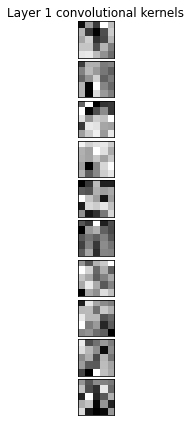

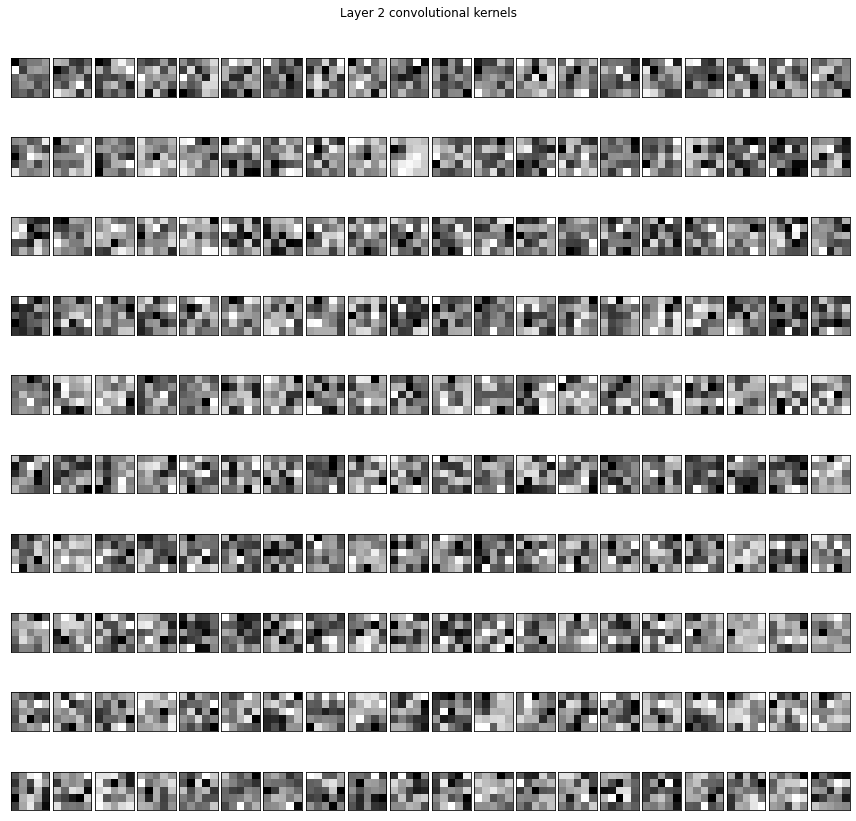

In [ ]:
### Extract weights 
# Layer 1 weights
weights_l1 = cnn1
# Layer 2 weights
weights_l2 = cnn2

### Plot the weights 
def plot_nchw_data(data, h_num, v_num, title, figsize):
    fig, axs = plt.subplots(h_num, v_num, figsize=figsize)
    shape = data.shape
    data = data.reshape(shape[0]*shape[1], shape[2], shape[3])
    for idx, ax in enumerate(axs.flatten()):
        ax.set_xticks([])
        ax.set_yticks([])
        if idx < len(data):
            ax.imshow(data[idx,:,:], cmap='gray')
    plt.suptitle(title)
    plt.tight_layout(rect=[0, 0, 1, 0.97], h_pad=0, w_pad=0)
    plt.show()

plot_nchw_data(weights_l1, 10, 1, 'Layer 1 convolutional kernels',(6,6))
plot_nchw_data(weights_l2, 10, 20, 'Layer 2 convolutional kernels',(12,12))

## Analyze activations

In [ ]:
print(best_model)

Register the forward hooks

In [ ]:
# Hook function to call during forward pass
def hook_fn(module, input, output):
    intermediate_outputs.append(output)

# Attach hook function to all the convolutional layers
hook_handles = [] # This list will contains all the handles required to remove the hooks later
hook_handles.append(best_model.conv1.register_forward_hook(hook_fn))
hook_handles.append(best_model.conv2.register_forward_hook(hook_fn))

Analyze the activations for a single input image

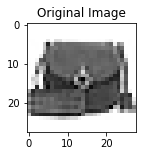

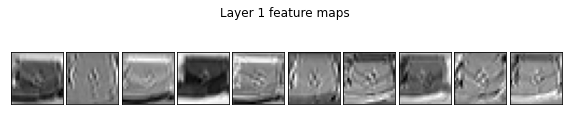

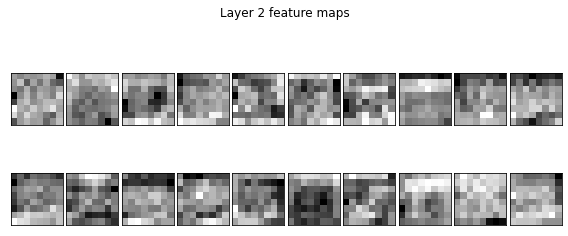

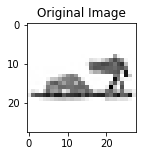

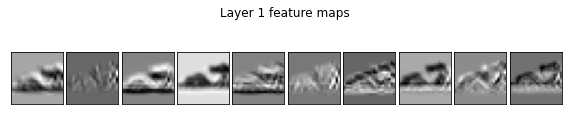

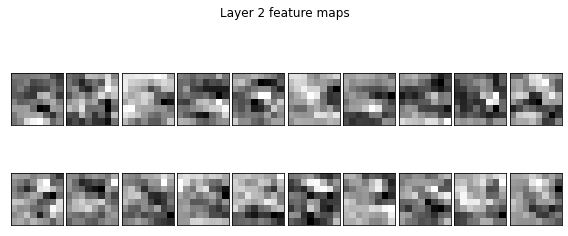

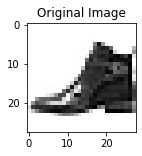

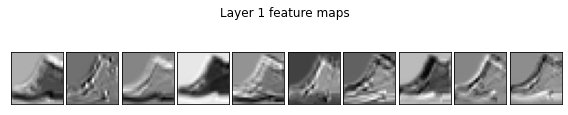

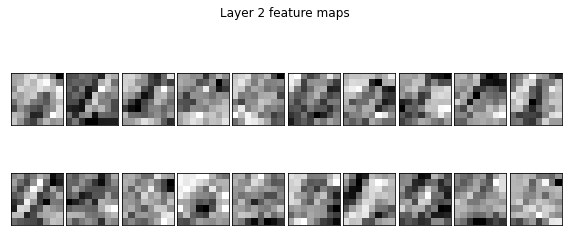

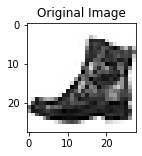

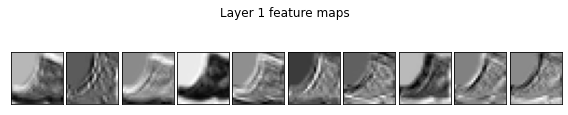

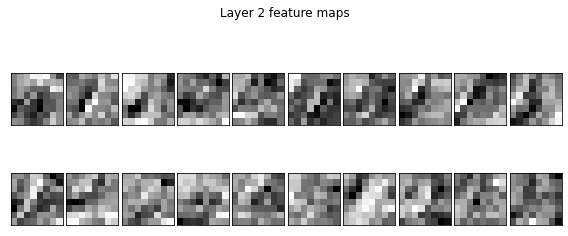

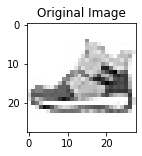

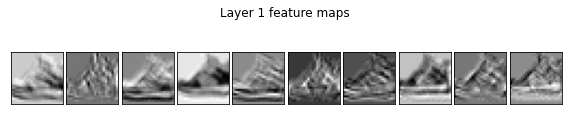

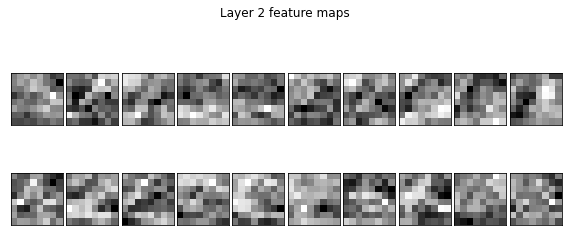

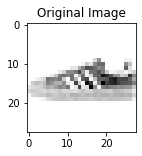

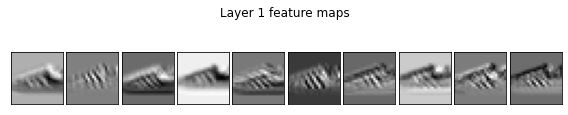

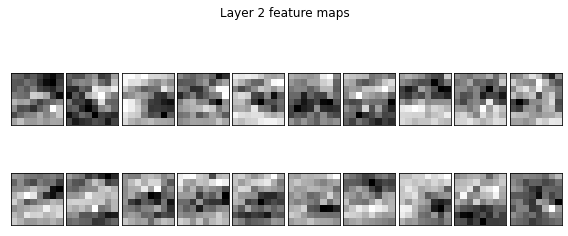

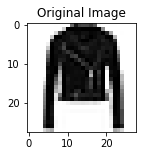

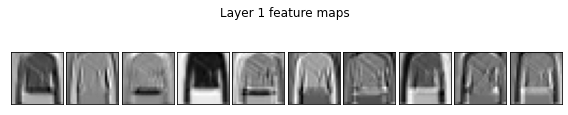

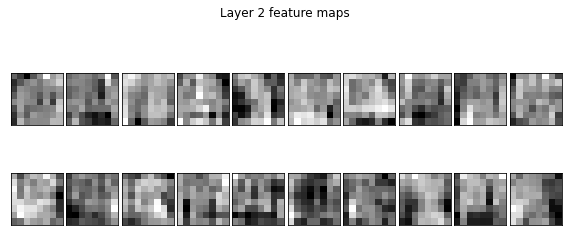

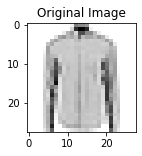

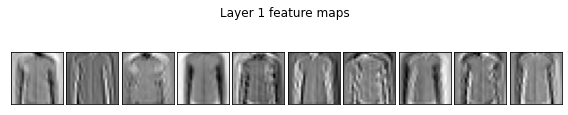

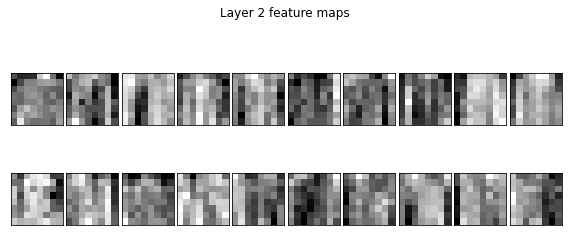

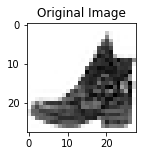

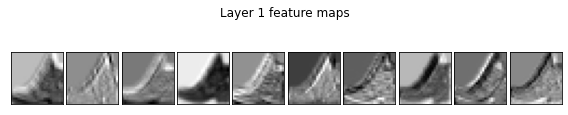

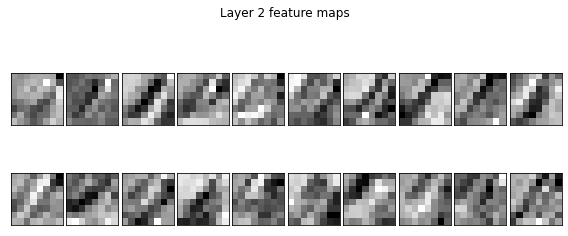

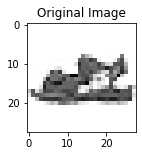

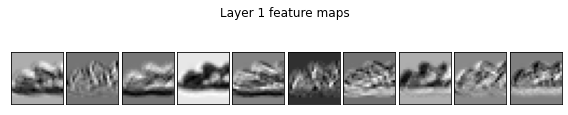

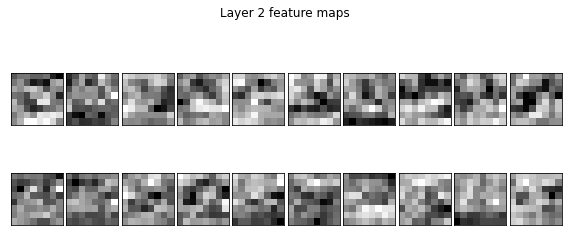

In [ ]:
for l in range(10):
# Define input
  input_i = random.randint(0, len(test_inputs))
  net_input = test_inputs[input_i][0].cpu()
  #net_input = net_input.to(device)

  # Show original image

  sample_image = torch.squeeze(net_input)
  fig = plt.figure(figsize=(2,2))
  plt.title('Original Image')
  plt.imshow(sample_image, cmap='Greys')
  plt.show()

  # Evaluate output
  best_model.eval()
  with torch.no_grad():
      intermediate_outputs = []
      net_input = net_input.unsqueeze(0)
      net_input = net_input.unsqueeze(0).to(device)
      out = best_model(net_input)
      # Now the intermediate_outputs list contains the intermediate outputs thanks to the hook function

  # Analyze intermediate outputs
  for layer_num, intermediate_output in enumerate(intermediate_outputs):
      intermediate_output = intermediate_output.cpu().data.numpy()
      # Plot
      i = layer_num + 1
      plot_nchw_data(intermediate_output, i, 10, 'Layer %d feature maps' % (layer_num + 1),(8,2*i))

Remove the registered forward hooks

In [ ]:
# Remove the hooks using the handles saved during the hooks definition
for handle in hook_handles:
  handle.remove()

## Bidimensional space visualization

Here we want to analyze the output of second last layer of the network. This is typically considered the *feature space*, since the last layer uses the information stored in these variables to perform the final classification.

A good feature space contains samples of different classes well spearated each other, and samples of the same class clustered together.

Since we cannot visualize such a high dimensional space, we need dimensionality reduction techniques to have an idea about this condition.

In [ ]:
print(best_model)

Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (conv2_drop): Dropout2d(p=0.16801027903950977, inplace=False)
  (conv2_bn): BatchNorm2d(20, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (fc1_bn): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1_drop): Dropout(p=0.16573496668551163, inplace=False)
  (fc1ReLU): ReLU()
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)


First, we need another forward hook to register the output of the second last layer.

In [ ]:
# Hook function to call during forward pass (extract second last layer features)
def hook_feature_space(module, input, output):
    feature_space.append(output) # feature_space must be a list defined before evaluating the network output

# Attach the hook function to layer fc1ReLU
hook_handle = best_model.fc1ReLU.register_forward_hook(hook_feature_space)

Since we now have the hook registered, when we evaluate the test outputs the `feature_space` list will be updated with the feature space values corresponding to the test samples.

In [ ]:
feature_space = [] # This list will be filled by the feature space values

### Analyze all the test samples
test_inputs, test_outputs, test_labels, test_loss = test_epoch(
    net=best_model,
    device=device, 
    dataloader=test_dataloader, 
    loss_fn=loss_fn)

# Concatenate all the features in a single tensor
feature_space = torch.cat(feature_space)

100%|██████████| 50/50 [00:01<00:00, 29.82it/s]


Let's verify if the list has been populated.

In [ ]:
print(feature_space.shape)

torch.Size([10000, 50])


Since the following analyses won't use PyTorch, let's move everything back to CPU.

In [ ]:
feature_space = feature_space.cpu()
test_labels   = test_labels.cpu()
test_outputs  = test_outputs.cpu()

### t-distributed Stochastic Neighbor Embedding

t-SNE [[ref]](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) is a tool to visualize high-dimensional data. It converts similarities between data points to joint probabilities and tries to minimize the Kullback-Leibler divergence between the joint probabilities of the low-dimensional embedding and the high-dimensional data. t-SNE has a cost function that is not convex, i.e. with different initializations we can get different results.

In [ ]:
### t-SNE embedding of the dataset (t-distributed Stochastic Neighbor Embedding)
print("Computing t-SNE embedding")
tsne = manifold.TSNE(n_components=2, init='pca', random_state=0)
feature_space_tsne = tsne.fit_transform(feature_space)

Computing t-SNE embedding


/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:986: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  FutureWarning,


In [ ]:
print(f"FEATURE SPACE SHAPE: {feature_space.shape}")
print(f"FEATURE SPACE SHAPE (TSNE): {feature_space_tsne.shape}")

FEATURE SPACE SHAPE: torch.Size([10000, 50])
FEATURE SPACE SHAPE (TSNE): (10000, 2)


Let's prepare a pandas dataframe just for plotting (no need to analyze this code)

In [ ]:
# Prepare dataframe for plotting (no need to analyze this code)
df = pd.DataFrame(feature_space_tsne)
df['label'] = test_labels
df['label_name'] = df.label.apply(lambda l: id_to_label[l])
df

,0,1,label,label_name
0,65.934166,-29.869549,9,Ankle boot
1,-50.366749,-34.996368,2,Pullover
2,0.434851,77.028076,1,Trouser
3,-6.591676,65.919495,1,Trouser
4,-45.604172,-1.236656,6,Shirt
...,...,...,...,...
9995,61.587559,-27.960888,9,Ankle boot
9996,-13.433751,51.714870,1,Trouser
9997,7.185036,-3.366404,8,Bag
9998,1.483470,51.413029,1,Trouser


In [ ]:
import plotly.express as px
### Plot
px.scatter(df, x=0, y=1, color='label_name', hover_data=[df.index])

### Isomap embedding

We can do the same thing with different type of dimensionality reduction methods, such as [Isometric Mapping Embedding](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html) (distance-preserving embedding).

In [ ]:
### Isomap embedding of the dataset
print("Computing Isomap")
isomap = manifold.Isomap(n_components=2)
feature_space_isomap = isomap.fit_transform(feature_space)

Computing Isomap


In [ ]:
print(f"FEATURE SPACE SHAPE: {feature_space.shape}")
print(f"FEATURE SPACE SHAPE (Isomap): {feature_space_isomap.shape}")

FEATURE SPACE SHAPE: torch.Size([10000, 50])
FEATURE SPACE SHAPE (Isomap): (10000, 2)


In [ ]:
# Prepare dataframe for plotting (no need to analyze this code)
df = pd.DataFrame(feature_space_isomap)
df['label'] = test_labels
df['label_name'] = df.label.apply(lambda l: id_to_label[l])

In [ ]:
### Plot
px.scatter(df, x=0, y=1, color='label_name', hover_data=[df.index])

# Comparison MLP-CNN

In [ ]:
#BEST MLP
#dropout = 0.6406806524045935
dropout = 0.8
lr = 0.0007503626278539724
weight_decay = 0.00028348475807963354
bestFF_model = Net(Ni, Nh1, Nh2, No, dropout).to(device)

# Define the loss function
loss_fn =  nn.CrossEntropyLoss()  
# Define the optimizer
optimizer = torch.optim.Adam(bestFF_model.parameters(), lr=lr, weight_decay=weight_decay)

train_dataloader = DataLoader(train_dataset, batch_size=200, shuffle=True, num_workers=2)

### TRAINING LOOP
train_accMLP, test_accMLP = [], []
num_epochs = 100
for epoch_num in range(num_epochs):

    print(f'# EPOCH {epoch_num+1}')
    accuracy = train_epoch(bestFF_model, device, train_dataloader, loss_fn, optimizer)
    train_accMLP.append(accuracy)

    accuracy = val_epoch(bestFF_model, device, test_dataloader, loss_fn)
    test_accMLP.append(accuracy)


# EPOCH 1
Average train loss: 0.49343281984329224, Accuracy: 49353/60000: 82.255%
Average validation loss: 0.38389816880226135, Accuracy: 8615/10000: 86.15%
# EPOCH 2
Average train loss: 0.38201218843460083, Accuracy: 51689/60000: 86.14833333333333%
Average validation loss: 0.37017232179641724, Accuracy: 8641/10000: 86.41%
# EPOCH 3
Average train loss: 0.35160329937934875, Accuracy: 52389/60000: 87.315%
Average validation loss: 0.36114180088043213, Accuracy: 8725/10000: 87.25%
# EPOCH 4
Average train loss: 0.3308137059211731, Accuracy: 52775/60000: 87.95833333333333%
Average validation loss: 0.4024411737918854, Accuracy: 8514/10000: 85.14%
# EPOCH 5
Average train loss: 0.3229157626628876, Accuracy: 52911/60000: 88.185%
Average validation loss: 0.3474857211112976, Accuracy: 8731/10000: 87.31%
# EPOCH 6
Average train loss: 0.3075672686100006, Accuracy: 53301/60000: 88.835%
Average validation loss: 0.3659418523311615, Accuracy: 8659/10000: 86.59%
# EPOCH 7
Average train loss: 0.2986750900

In [ ]:
#BEST CNN
dropout = 0.16801027903950977
dropout_ff = 0.16573496668551163
lr = 0.0007596118658217216
weight_decay = 4.2556387066313155e-05

best_model = Net(dropout,dropout_ff).to(device)
train_dataloader = DataLoader(train_dataset, batch_size=200, shuffle=True, num_workers=2)

# Define the loss function
loss_fn =  nn.CrossEntropyLoss()  
# Define the optimizer
optimizer = torch.optim.Adam(best_model.parameters(), lr=lr, weight_decay=weight_decay)

num_epochs = 100     #1epoch=1iter over your data
train_accCNN, test_accCNN = [], []
for epoch_num in range(num_epochs):

    print(f'# EPOCH {epoch_num}')
    accuracy = train_epoch(best_model, device, train_dataloader, loss_fn, optimizer)
    train_accCNN.append(accuracy)

    accuracy = val_epoch(best_model, device, test_dataloader, loss_fn)
    test_accCNN.append(accuracy)


# EPOCH 0
Average train loss: 0.7757882475852966, Accuracy: 46285/60000: 77.14166666666667%
Average validation loss: 0.4429267942905426, Accuracy: 8492/10000: 84.92%
# EPOCH 1
Average train loss: 0.41772401332855225, Accuracy: 51446/60000: 85.74333333333334%
Average validation loss: 0.3515729606151581, Accuracy: 8761/10000: 87.61%
# EPOCH 2
Average train loss: 0.35946646332740784, Accuracy: 52374/60000: 87.29%
Average validation loss: 0.32506996393203735, Accuracy: 8833/10000: 88.33%
# EPOCH 3
Average train loss: 0.3305065631866455, Accuracy: 52913/60000: 88.18833333333333%
Average validation loss: 0.31978729367256165, Accuracy: 8806/10000: 88.06%
# EPOCH 4
Average train loss: 0.31425875425338745, Accuracy: 53251/60000: 88.75166666666667%
Average validation loss: 0.29958376288414, Accuracy: 8922/10000: 89.22%
# EPOCH 5
Average train loss: 0.29865601658821106, Accuracy: 53533/60000: 89.22166666666666%
Average validation loss: 0.2963278889656067, Accuracy: 8923/10000: 89.23%
# EPOCH 6
Av

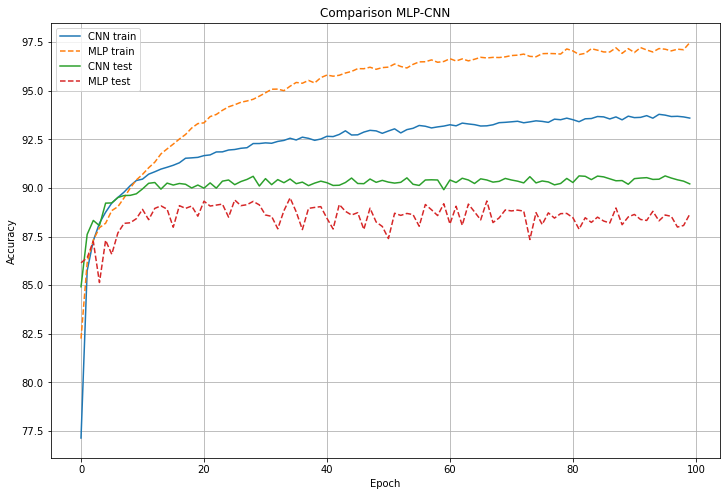

In [ ]:
# Plot losses
plt.figure(figsize=(12,8))
plt.title('Comparison MLP-CNN')
plt.plot(train_accCNN, label='CNN train')
plt.plot(train_accMLP, label='MLP train', linestyle='--')
plt.plot(test_accCNN, label='CNN test')
plt.plot(test_accMLP, label='MLP test', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.show()

In [15]:
import nbformat
import os

# Path to your notebook
notebook_path = "/Users/lgreggio/Neural-network-and-deep-learning/Classification/Classification.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

for cell in nb.cells:
    if 'widgets' in cell.metadata:
        del cell.metadata['widgets']

with open(notebook_path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print(f"Notebook '{notebook_path}' cleaned for GitHub rendering!")


Notebook '/Users/lgreggio/Neural-network-and-deep-learning/Classification/Classification.ipynb' cleaned for GitHub rendering!
